In [2]:
pip install pandas matplotlib openpyxl

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [7]:
import os

print(os.listdir())

['.ipynb_checkpoints', 'clean_data.ipynb', 'sales_data.csv.xlsx']


In [9]:
import os
print(os.getcwd())
print(os.listdir())

C:\Users\visha\Downloads\data set
['.ipynb_checkpoints', 'clean_data.ipynb', 'sales_data.csv.xlsx']


In [14]:
import pandas as pd

df = pd.read_csv("data set.csv")

display(df)

,Order_ID,Customer_Name,Region,Sales,Date,Category
0,1001,john,West,500.0,01-01-2026,electronics
1,1002,Anna,East,700.0,02-01-2026,Furniture
2,1003,john,West,500.0,01-01-2026,electronics
3,1004,Mike,NaN,300.0,03-01-2026,clothing
4,1005,Sara,North,NaN,05-01-2026,Electronics
5,1006,DAVID,South,900.0,06-01-2026,FURNITURE
6,1007,anna,East,450.0,07-01-2026,furniture
7,1008,Tom,West,650.0,08-01-2026,Clothing


ORIGINAL DATA
   Order_ID Customer_Name Region  Sales        Date     Category
0      1001          john   West  500.0  01-01-2026  electronics
1      1002          Anna   East  700.0  02-01-2026    Furniture
2      1003          john   West  500.0  01-01-2026  electronics
3      1004          Mike    NaN  300.0  03-01-2026     clothing
4      1005          Sara  North    NaN  05-01-2026  Electronics
5      1006         DAVID  South  900.0  06-01-2026    FURNITURE
6      1007          anna   East  450.0  07-01-2026    furniture
7      1008           Tom   West  650.0  08-01-2026     Clothing

CLEANED DATA
   Order_ID Customer_Name   Region       Sales       Date     Category
0      1001          John     West  500.000000 2026-01-01  Electronics
1      1002          Anna     East  700.000000 2026-02-01    Furniture
2      1003          John     West  500.000000 2026-01-01  Electronics
3      1004          Mike  Unknown  300.000000 2026-03-01     Clothing
4      1005          Sara    Nor

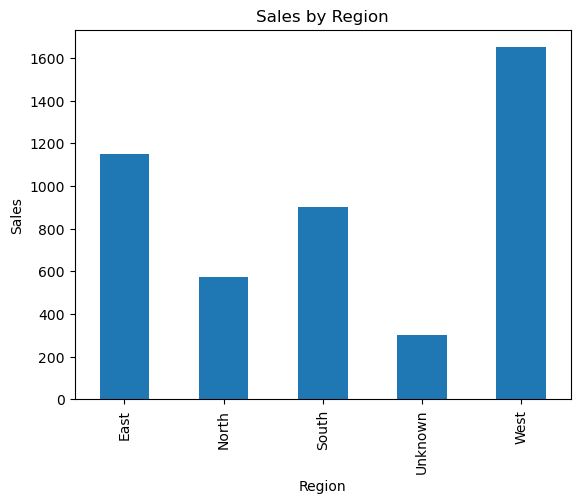

In [16]:
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------
# LOAD DATA
# -----------------------------
df = pd.read_csv("sales_data.csv")

print("ORIGINAL DATA")
print(df)

# -----------------------------
# REMOVE DUPLICATES
# -----------------------------
df = df.drop_duplicates()

# -----------------------------
# HANDLE MISSING VALUES
# -----------------------------

# Fill missing Region
df['Region'] = df['Region'].fillna('Unknown')

# Fill missing Sales with average
df['Sales'] = df['Sales'].fillna(df['Sales'].mean())

# -----------------------------
# FIX TEXT FORMATTING
# -----------------------------

# Customer names proper format
df['Customer_Name'] = df['Customer_Name'].str.title()

# Category proper format
df['Category'] = df['Category'].str.title()

# -----------------------------
# CONVERT DATE FORMAT
# -----------------------------
df['Date'] = pd.to_datetime(df['Date'])

# -----------------------------
# SAVE CLEANED DATA
# -----------------------------
df.to_excel("cleaned_sales_report.xlsx", index=False)

print("\nCLEANED DATA")
print(df)

# -----------------------------
# CREATE SALES SUMMARY
# -----------------------------
summary = df.groupby('Region')['Sales'].sum()

print("\nSALES SUMMARY")
print(summary)

# -----------------------------
# CREATE BAR CHART
# -----------------------------
summary.plot(kind='bar')

plt.title("Sales by Region")
plt.xlabel("Region")
plt.ylabel("Sales")

# Save chart
plt.savefig("sales_chart.png")

plt.show()